In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

In [3]:
data = pd.read_csv('machine_temperature_system_failure.csv')
data.rename(columns = {'value':'temperature'}, inplace = True)
data = data.set_index('timestamp')

In [4]:
def create_sequences(data, window_size=50):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i : i + window_size])      # 50 timesteps
        y.append(data.iloc[i + window_size])           # next value
    return np.array(X), np.array(y)

X, y = create_sequences(data, window_size=50)

In [5]:
X = np.squeeze(X)
#y = np.squeeze(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
y_test_df = pd.DataFrame({'Temperature': np.squeeze(y_test)})

In [ ]:
y_test_df

In [7]:
X_train.shape, y_train.shape

((18116, 50), (18116, 1))

In [8]:
#numeric_features = ['temperature']
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.transform(y_test)

In [9]:
class LanguageModelDataLoader(DataLoader):
    def __init__(self, X_train, y_train, batch_size, shuffle=True):
        self.batch_size = batch_size
        self.cuda = False
        self.X_train = X_train
        self.y_train = y_train

    def __iter__(self):
        # concatenate your articles and build into batches
        count = len(self.X_train)
        num_batches = (count - 1)//self.batch_size
        number = num_batches * self.batch_size
        
        x = torch.from_numpy(self.X_train)
        y = torch.from_numpy(self.y_train)
        if self.cuda:
            x = x.cuda()
            y = y.cuda()
        
        start = 0
        while start < num_batches:
            # if (np.random.uniform() < 0.95):
            #     L = round(np.random.normal(70,5))
            # else:
            #     L = round(np.random.normal(35,5))
            L = self.batch_size
            x_out = x[start:start + L]
            y_out = y[start:start + L]
            x_out = x_out.reshape(x_out.shape[0], 1, x_out.shape[1])
            start = start + L
            #print(x_out.shape, y_out.shape)
            yield x_out, y_out 

In [10]:
class LanguageModel(nn.Module):
    def __init__(self):
        super(LanguageModel, self).__init__()
        # self.vocab_size = charcount
        # self.embedding = nn.Embedding(self.vocab_size,400)
        self.cnn = nn.ModuleList()
        self.cnn.append(nn.Conv1d(in_channels = 1, out_channels = 32, kernel_size = 3, padding = 'same'))
        self.cnn.append(nn.ReLU())
        self.cnn.append(nn.Conv1d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 'same'))
        self.cnn.append(nn.ReLU())
        self.cnn.append(nn.Flatten())
        self.cnn.append(nn.Dropout(p = 0.3))
        self.cnn.append(nn.Linear(64 * 50 , 1))
        
    def forward(self, out):
        #embed = self.embedding(seq_batch)
        #print(out.dtype)
        for layers in self.cnn:
            out = layers(out)
        #print(out.size())
        return out

In [11]:
class LanguageModelTrainer:
    def __init__(self, model, loader, X_test, y_test, max_epochs=1, run_id='exp'):
        # feel free to add any other parameters here
        self.model = model
        self.loader = loader
        self.predictions = []
        self.epochs = 0
        self.max_epochs = max_epochs
        self.run_id = run_id
        self.train_losses = []
        self.val_losses = []
        
        self.X_test = torch.from_numpy(X_test)
        self.y_test = torch.from_numpy(y_test)
        
        # TODO: Define your optimizer and criterion here
        self.optimizer = torch.optim.Adam(model.parameters(),lr=0.001, weight_decay=1e-6)
        self.criterion = nn.MSELoss().to(DEVICE)

    def train(self):
        self.model.train() # set to training mode
        epoch_loss = 0
        num_batches = 0
        for batch_num, (inputs, targets) in enumerate(self.loader):
            epoch_loss += self.train_batch(inputs, targets)
        epoch_loss = epoch_loss / (batch_num + 1)
        predictions = torch.from_numpy(TestLanguageModel.prediction(X_test, self.model))
        #preds, score = accuracy(predictions, self.y_test)
        val_loss = self.criterion(predictions.to(torch.float32), self.y_test.to(torch.float32))
        self.epochs += 1
        if self.epochs % 5 == 0:
            print('[TRAIN]  Epoch [%d/%d]   Loss: %.4f [VALID LOSS] %.4f'
                      % (self.epochs, self.max_epochs, epoch_loss.item(), val_loss))
        self.train_losses.append(epoch_loss.item())
        self.val_losses.append(val_loss)

    def train_batch(self, inputs, targets):
        inputs = inputs.to(DEVICE).long()
        targets = targets.to(torch.float32)
        outputs = self.model(inputs.to(torch.float32))
        #print((outputs[:,0]), (outputs[:,1]), targets)
        loss = self.criterion(outputs.view(-1), targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss

In [12]:
class TestLanguageModel:
    def prediction(inp, model):
        model.eval()
        inp = inp.reshape(inp.shape[0], 1, inp.shape[1])
        inp = torch.from_numpy(inp)
        inp = inp.to(torch.float32)
        h = model(inp)
        #print(h.shape, h)
        return h.cpu().data.numpy()

In [13]:
#hyperparameters here

NUM_EPOCHS = 50
BATCH_SIZE = 64

In [14]:
model = LanguageModel()
loader = LanguageModelDataLoader(X_train = X_train, y_train = y_train, batch_size=BATCH_SIZE, shuffle=True)
trainer = LanguageModelTrainer(model=model, loader=loader, max_epochs=NUM_EPOCHS, X_test = X_test, y_test = y_test)

In [ ]:
#Loading a pre-trained model

loadedModel = LanguageModel()
loadedModel.load_state_dict(torch.load('./experiments/model.pkl', weights_only = True))
loadedModel.eval()

In [15]:
model = model.to(DEVICE)

In [24]:
best_nll = 1e30  # set to super large value at first
for epoch in range(NUM_EPOCHS):
    trainer.train()
    predictions = torch.from_numpy(TestLanguageModel.prediction(X_test, model))
    #predictions_fromLoadedModel = last_layer(torch.from_numpy(TestLanguageModel.prediction(np.array(X_test), loadedModel)))
    # nll = trainer.test()
    # if nll < best_nll:
    #     best_nll = nll
    #     print("Saving model, predictions and generated output for epoch " + 
    #           str(epoch)+" with NLL: " + str(best_nll))
    #     trainer.save()

[TRAIN]  Epoch [155/50]   Loss: 0.1929 [VALID LOSS] 1.1005
[TRAIN]  Epoch [160/50]   Loss: 0.1922 [VALID LOSS] 1.0965
[TRAIN]  Epoch [165/50]   Loss: 0.1919 [VALID LOSS] 1.0608
[TRAIN]  Epoch [170/50]   Loss: 0.1944 [VALID LOSS] 1.0622
[TRAIN]  Epoch [175/50]   Loss: 0.1924 [VALID LOSS] 1.0615
[TRAIN]  Epoch [180/50]   Loss: 0.1924 [VALID LOSS] 1.0249
[TRAIN]  Epoch [185/50]   Loss: 0.1970 [VALID LOSS] 1.0012
[TRAIN]  Epoch [190/50]   Loss: 0.1933 [VALID LOSS] 1.0062
[TRAIN]  Epoch [195/50]   Loss: 0.1919 [VALID LOSS] 0.9911
[TRAIN]  Epoch [200/50]   Loss: 0.1923 [VALID LOSS] 1.0223


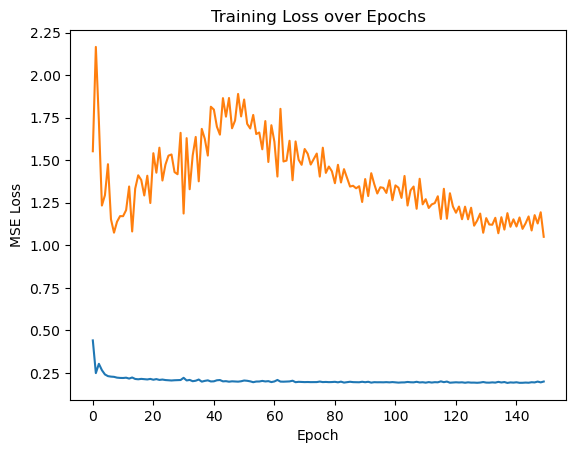

In [19]:
plt.plot(trainer.train_losses)
plt.plot(trainer.val_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

In [ ]:
#Saving the model

model_path = os.path.join('experiments', 'model.pkl')
torch.save(model.state_dict(),
            model_path)

In [25]:
predictions = sc_y.inverse_transform(predictions)
y_test = y_test.reshape(-1, 1)
print(predictions.shape, y_test.shape)

y_test = sc_y.inverse_transform(y_test)


out = pd.DataFrame({'Predictions': np.squeeze(predictions), 'Actual_output': np.squeeze(y_test)})

(18116, 1) (4529, 1)


ValueError: All arrays must be of the same length

In [ ]:
predictions, y_test

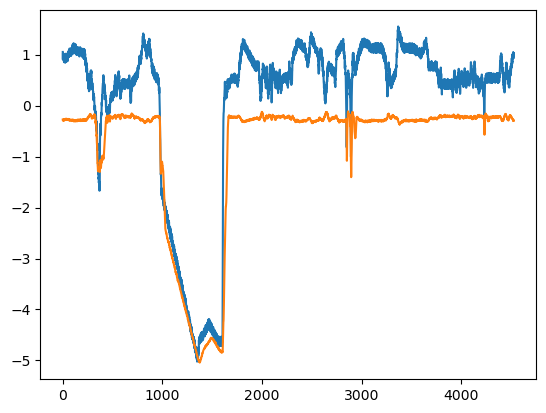

In [20]:
plt.plot(y_test)
plt.plot(predictions)
plt.show()

In [21]:
errors = np.abs(np.squeeze(predictions.numpy()) - np.squeeze(y_test))
threshold = np.mean(errors) + 3 * np.std(errors)
anomalies = errors > threshold

In [22]:
print(np.squeeze(predictions).shape, np.squeeze(y_test).shape, anomalies.shape)
out = pd.DataFrame({'Predictions': np.squeeze(predictions), 'Actual_output': np.squeeze(y_test), 'Outlier' : np.squeeze(anomalies)})

torch.Size([4529]) (4529,) (4529,)


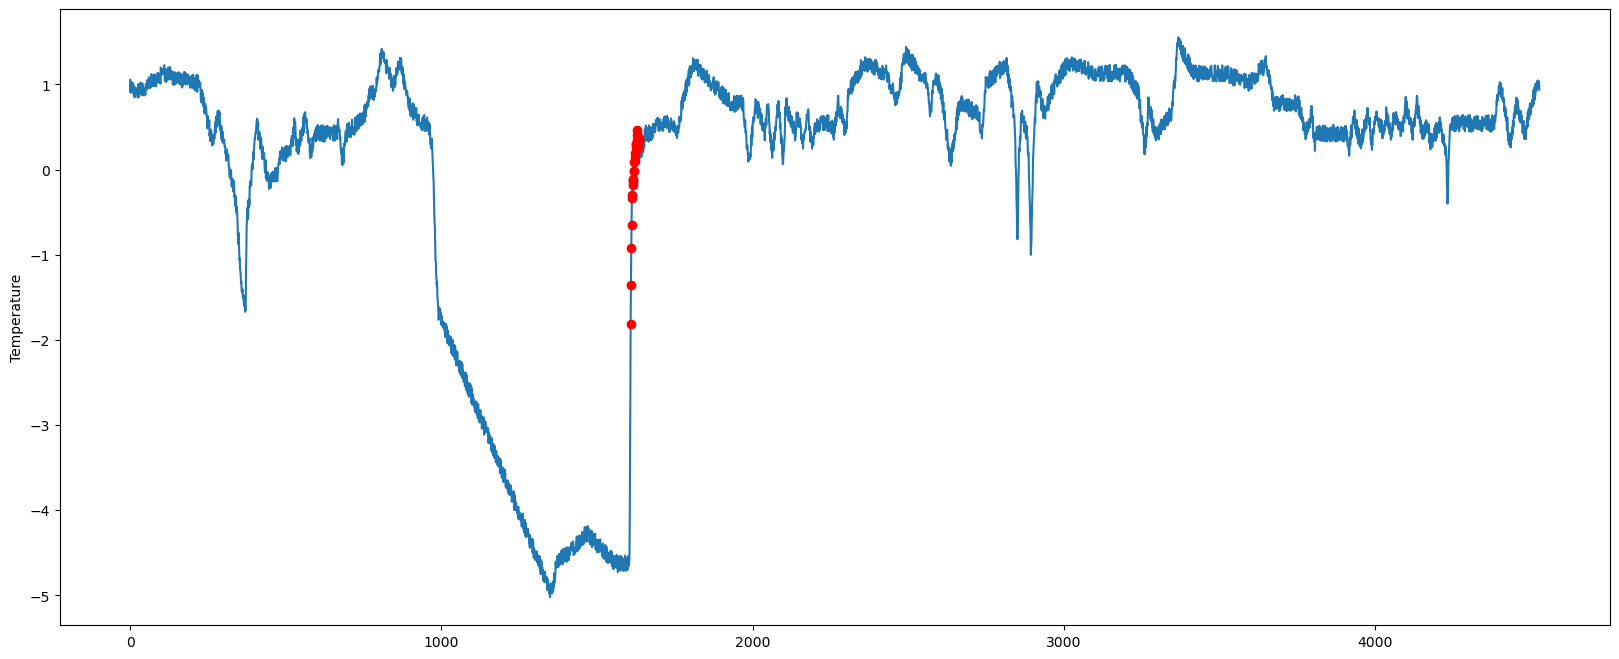

In [23]:
fig, ax1 = plt.subplots(1, sharex=True, figsize=(20, 8))
ax1.plot(y_test_df.index, out['Actual_output'], label='Temperature')
#ax1.plot(data[data['residual_flag'] == False].index, data[data['residual_flag'] == False], 'o', color='g', label='Normal Temp')
ax1.plot(out[out['Outlier'] == True].index, out[out['Outlier'] == True]['Actual_output'], 'o', color='r', label='Outlier')
ax1.set_ylabel('Temperature')
plt.show()

In [ ]:
out[out['Outlier'] == True]